In [1]:
!pip install sentence-transformers xgboost wordcloud scikit-learn pandas numpy matplotlib seaborn --quiet
print("✅ All libraries installed!")

✅ All libraries installed!


In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("✅ All libraries imported!")

✅ All libraries imported!


In [3]:
# Your Tweets.csv is already uploaded in Colab!
df = pd.read_csv('Tweets.csv')

print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n🔍 First 5 rows:")
df.head()

✅ Dataset loaded successfully!
   Shape: 27481 rows × 4 columns

🔍 First 5 rows:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
print("📋 Columns:", df.columns.tolist())
print("\n📐 Shape:", df.shape)
print("\n❓ Missing Values:")
print(df.isnull().sum())
print("\n🏷️ Unique Sentiments:", df['sentiment'].unique())
print("\n📊 Sentiment Counts:")
print(df['sentiment'].value_counts())

📋 Columns: ['textID', 'text', 'selected_text', 'sentiment']

📐 Shape: (27481, 4)

❓ Missing Values:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64

🏷️ Unique Sentiments: ['neutral' 'negative' 'positive']

📊 Sentiment Counts:
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


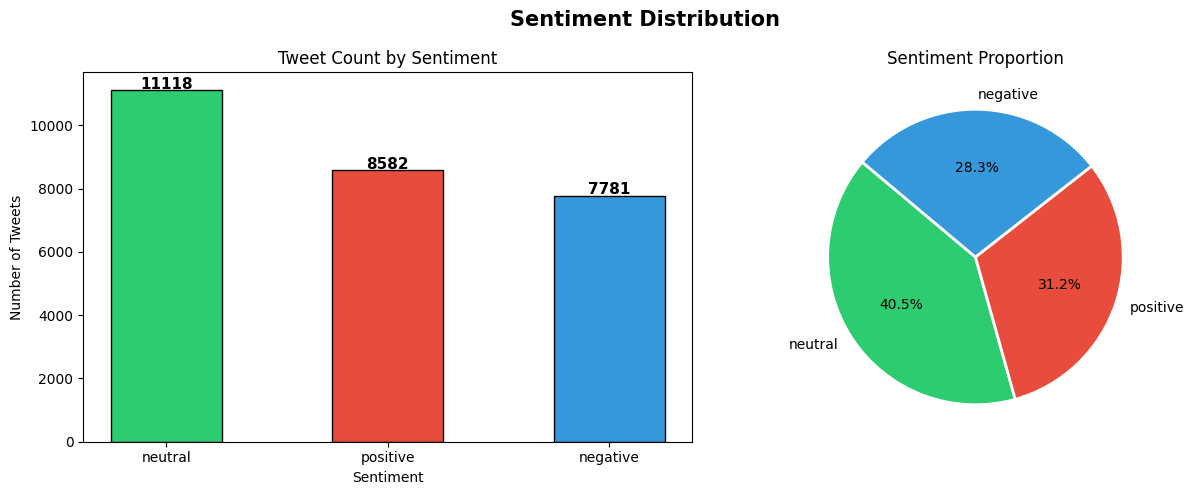


📌 Observation:
  Positive : 8582
  Negative : 7781
  Neutral  : 11118
  Dataset may be slightly imbalanced — this can affect model predictions.


In [5]:
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sentiment Distribution', fontsize=15, fontweight='bold')

# Bar chart
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Tweet Count by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')
for bar, val in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 40, str(val),
                 ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Sentiment Proportion')

plt.tight_layout()
plt.show()

print("\n📌 Observation:")
print(f"  Positive : {sentiment_counts.get('positive', 0)}")
print(f"  Negative : {sentiment_counts.get('negative', 0)}")
print(f"  Neutral  : {sentiment_counts.get('neutral', 0)}")
print("  Dataset may be slightly imbalanced — this can affect model predictions.")

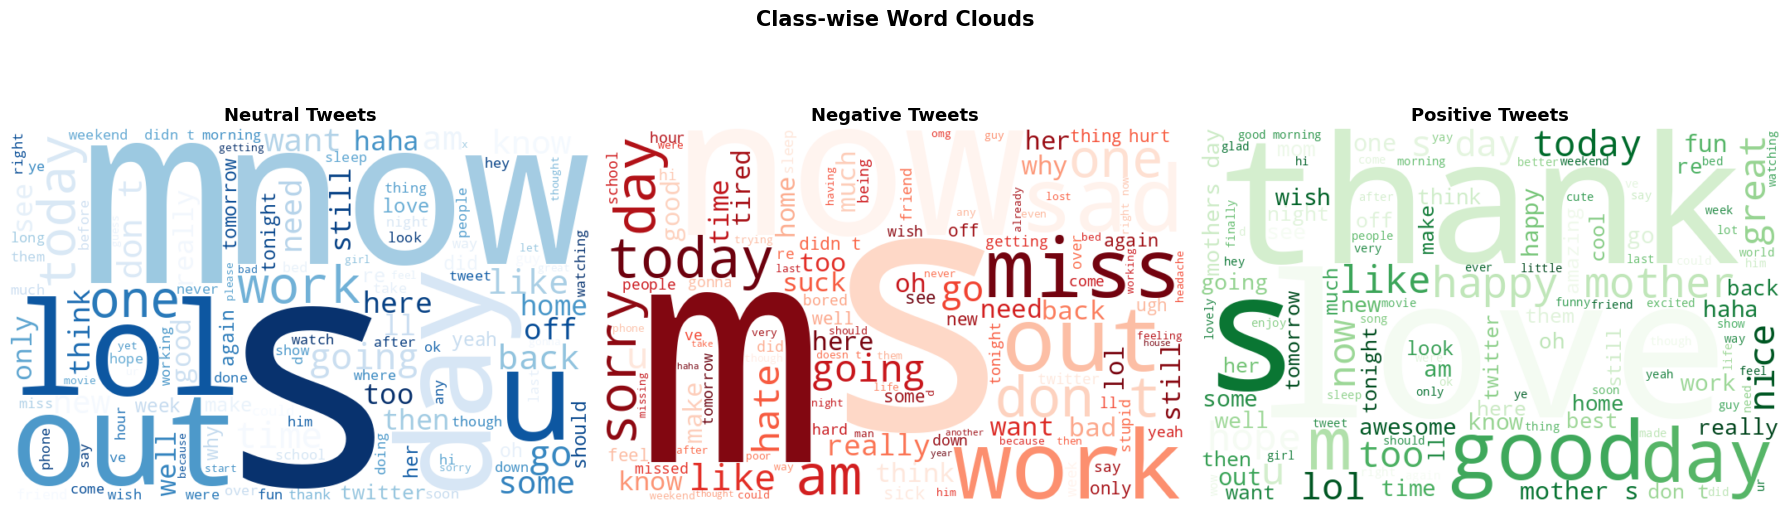

📌 Observation:
  Positive cloud → words like 'love', 'great', 'amazing'
  Negative cloud → words like 'hate', 'bad', 'terrible'
  Neutral cloud  → factual words, no strong emotion


In [6]:
STOPWORDS = {
    'the','and','to','a','of','in','is','it','that','this',
    'i','for','on','with','are','was','be','at','by','an',
    'we','as','from','have','has','had','but','not','they',
    'so','if','all','do','my','your','or','can','will','just',
    'me','you','he','she','their','our','its','more','about',
    'been','up','would','there','what','when','which','who',
    'how','no','get','got','im','dont','amp','rt','via'
}

unique_sentiments = df['sentiment'].unique()
sentiment_colors = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

fig, axes = plt.subplots(1, len(unique_sentiments), figsize=(18, 6))
fig.suptitle('Class-wise Word Clouds', fontsize=15, fontweight='bold')

for idx, sentiment in enumerate(unique_sentiments):
    text = ' '.join(df[df['sentiment'] == sentiment]['text'].astype(str).tolist())
    text = re.sub(r'http\S+|@\w+|[^A-Za-z\s]', ' ', text).lower()

    cmap = sentiment_colors.get(sentiment, 'Purples')
    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap=cmap,
        max_words=120,
        stopwords=STOPWORDS
    ).generate(text)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{sentiment.capitalize()} Tweets', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 Observation:")
print("  Positive cloud → words like 'love', 'great', 'amazing'")
print("  Negative cloud → words like 'hate', 'bad', 'terrible'")
print("  Neutral cloud  → factual words, no strong emotion")

📊 Text Length Stats by Sentiment:
          char_count                                           word_count  \
               count  mean   std  min   25%   50%   75%    max      count   
sentiment                                                                   
negative      7781.0  70.5  35.2  5.0  42.0  66.0  98.0  141.0     7781.0   
neutral      11118.0  65.2  36.4  3.0  34.2  59.0  94.0  141.0    11118.0   
positive      8582.0  70.4  34.6  5.0  42.0  67.0  98.0  138.0     8582.0   

                                                  
           mean  std  min  25%   50%   75%   max  
sentiment                                         
negative   13.5  6.9  1.0  8.0  13.0  19.0  32.0  
neutral    12.3  7.1  1.0  6.0  11.0  18.0  33.0  
positive   13.1  6.7  1.0  8.0  12.0  18.0  33.0  


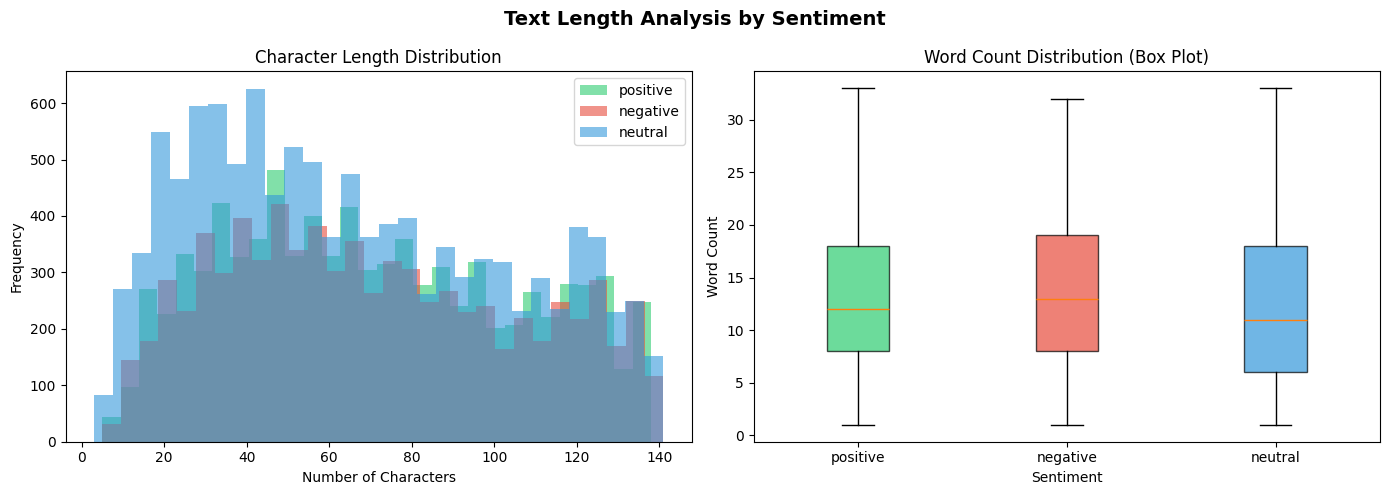


📌 Observation:
  Most tweets are 5–30 words (Twitter's character limit).
  Negative tweets tend to be slightly longer.
  Neutral tweets are shorter and more factual.


In [7]:
df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("📊 Text Length Stats by Sentiment:")
print(df.groupby('sentiment')[['char_count', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Text Length Analysis by Sentiment', fontsize=14, fontweight='bold')

sent_color = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}

# Histogram
for sent, col in sent_color.items():
    subset = df[df['sentiment'] == sent]['char_count']
    if len(subset) > 0:
        axes[0].hist(subset, bins=30, alpha=0.6, label=sent, color=col)
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot
sentiments_list = list(sent_color.keys())
data_to_plot = [df[df['sentiment'] == s]['word_count'].dropna().values for s in sentiments_list]
bp = axes[1].boxplot(data_to_plot, labels=sentiments_list, patch_artist=True)
for patch, col in zip(bp['boxes'], sent_color.values()):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
axes[1].set_title('Word Count Distribution (Box Plot)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

print("\n📌 Observation:")
print("  Most tweets are 5–30 words (Twitter's character limit).")
print("  Negative tweets tend to be slightly longer.")
print("  Neutral tweets are shorter and more factual.")

In [8]:
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)    # Remove URLs
    text = re.sub(r'@\w+', '', text)              # Remove @mentions
    text = re.sub(r'#', '', text)                 # Remove # symbol
    text = re.sub(r'[^A-Za-z\s]', '', text)       # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()      # Remove extra spaces
    text = text.lower()                           # Lowercase
    return text

print("🧹 Cleaning tweets...")
df['cleaned_text'] = df['text'].apply(clean_tweet)
df = df[df['cleaned_text'].str.strip().str.len() > 3].reset_index(drop=True)

print(f"✅ Done! {len(df)} tweets remaining.")
print("\n📝 Before vs After (3 examples):")
for i in range(3):
    print(f"\n  Original : {df['text'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned_text'].iloc[i]}")

🧹 Cleaning tweets...
✅ Done! 27443 tweets remaining.

📝 Before vs After (3 examples):

  Original :  I`d have responded, if I were going
  Cleaned  : id have responded if i were going

  Original :  Sooo SAD I will miss you here in San Diego!!!
  Cleaned  : sooo sad i will miss you here in san diego

  Original : my boss is bullying me...
  Cleaned  : my boss is bullying me


In [9]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("🏷️ Label Encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  '{cls}' → {i}")

print(f"\n✅ Done! Labels: {sorted(df['label'].unique())}")

🏷️ Label Encoding:
  'negative' → 0
  'neutral' → 1
  'positive' → 2

✅ Done! Labels: [np.int64(0), np.int64(1), np.int64(2)]


In [10]:
print("⏳ Loading SentenceTransformer model...")
print("   (First time: downloads ~80MB, takes 1-2 mins)")

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print("\n✅ Model loaded!")
print("   Model  : all-MiniLM-L6-v2")
print("   Output : Each tweet → 384 numbers")

⏳ Loading SentenceTransformer model...
   (First time: downloads ~80MB, takes 1-2 mins)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


✅ Model loaded!
   Model  : all-MiniLM-L6-v2
   Output : Each tweet → 384 numbers


In [11]:
print(f"⏳ Generating embeddings for {len(df)} tweets...")
print("   This takes 5-15 minutes, progress bar below:")

embeddings = embedding_model.encode(
    df['cleaned_text'].tolist(),
    batch_size=256,
    show_progress_bar=True
)

print(f"\n✅ Done! Shape: {embeddings.shape}")
print(f"   = {embeddings.shape[0]} tweets × {embeddings.shape[1]} dimensions")
print(f"   First tweet sample (5 values): {embeddings[0][:5].round(4)}")

⏳ Generating embeddings for 27443 tweets...
   This takes 5-15 minutes, progress bar below:


Batches:   0%|          | 0/108 [00:00<?, ?it/s]


✅ Done! Shape: (27443, 384)
   = 27443 tweets × 384 dimensions
   First tweet sample (5 values): [-0.0115  0.0057  0.0519  0.0765  0.0083]


🔍 Example Tweets:
  T1: I love this product, it is absolutely amazing!
  T2: This is fantastic, I am so happy with the result!
  T3: I hate this so much, it is terrible and disappointing
  T4: The product was delivered on Tuesday afternoon

Cosine Similarity Matrix:
       T1     T2     T3     T4
T1  1.000  0.465  0.278  0.294
T2  0.465  1.000  0.261  0.224
T3  0.278  0.261  1.000  0.063
T4  0.294  0.224  0.063  1.000

💡 T1 vs T2 (both positive) : 0.465 → High similarity ✅
💡 T1 vs T3 (pos vs neg)    : 0.278 → Low similarity ✅


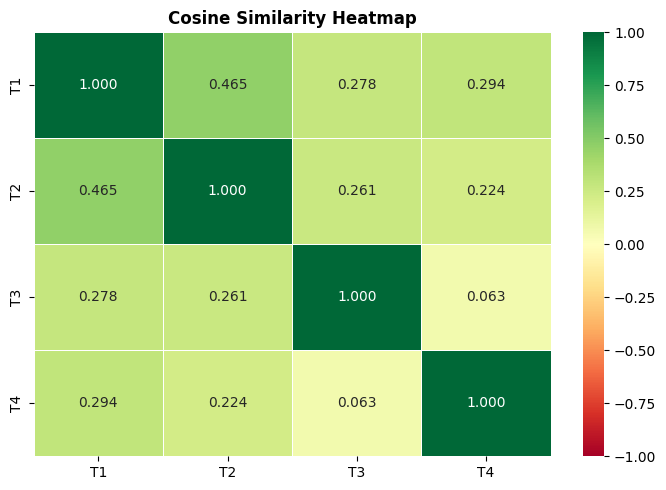

In [12]:
example_tweets = [
    "I love this product, it is absolutely amazing!",
    "This is fantastic, I am so happy with the result!",
    "I hate this so much, it is terrible and disappointing",
    "The product was delivered on Tuesday afternoon"
]

ex_embeddings = embedding_model.encode(example_tweets)
sim_matrix = cosine_similarity(ex_embeddings)

labels = [f'T{i+1}' for i in range(len(example_tweets))]
print("🔍 Example Tweets:")
for i, t in enumerate(example_tweets):
    print(f"  T{i+1}: {t}")

print("\nCosine Similarity Matrix:")
sim_df = pd.DataFrame(sim_matrix.round(3), index=labels, columns=labels)
print(sim_df)

print(f"\n💡 T1 vs T2 (both positive) : {sim_matrix[0][1]:.3f} → High similarity ✅")
print(f"💡 T1 vs T3 (pos vs neg)    : {sim_matrix[0][2]:.3f} → Low similarity ✅")

plt.figure(figsize=(7, 5))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels,
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Cosine Similarity Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
X = embeddings
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Done!")
print(f"   Training samples  : {X_train.shape[0]}")
print(f"   Testing  samples  : {X_test.shape[0]}")
print(f"   Features per tweet: {X_train.shape[1]}")

✅ Train-Test Split Done!
   Training samples  : 21954
   Testing  samples  : 5489
   Features per tweet: 384


In [14]:
print("⏳ Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial'
)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)
lr_f1    = f1_score(y_test, lr_preds, average='weighted')

print(f"✅ Done!")
print(f"   Accuracy : {lr_acc*100:.2f}%")
print(f"   F1 Score : {lr_f1:.4f}")

⏳ Training Logistic Regression...
✅ Done!
   Accuracy : 68.01%
   F1 Score : 0.6809


In [15]:
print("⏳ Training XGBoost... (2-5 minutes)")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)
xgb_f1    = f1_score(y_test, xgb_preds, average='weighted')

print(f"✅ Done!")
print(f"   Accuracy : {xgb_acc*100:.2f}%")
print(f"   F1 Score : {xgb_f1:.4f}")

⏳ Training XGBoost... (2-5 minutes)
✅ Done!
   Accuracy : 66.42%
   F1 Score : 0.6648


           MODEL COMPARISON
  Model                       Accuracy       F1
----------------------------------------------------
  Logistic Regression           68.01%   0.6809
  XGBoost                       66.42%   0.6648
  🏆 Best Model: Logistic Regression


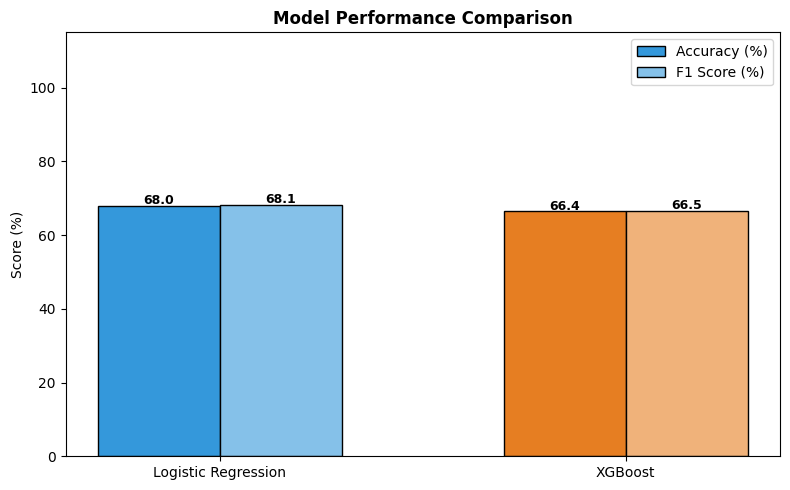

In [16]:
print("=" * 52)
print("           MODEL COMPARISON")
print("=" * 52)
print(f"  {'Model':<25} {'Accuracy':>10} {'F1':>8}")
print("-" * 52)
print(f"  {'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_f1:>8.4f}")
print(f"  {'XGBoost':<25} {xgb_acc*100:>9.2f}% {xgb_f1:>8.4f}")
print("=" * 52)

if xgb_acc >= lr_acc:
    best_model, best_preds, best_name = xgb_model, xgb_preds, 'XGBoost'
else:
    best_model, best_preds, best_name = lr_model, lr_preds, 'Logistic Regression'

print(f"  🏆 Best Model: {best_name}")
print("=" * 52)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
w = 0.3
b1 = ax.bar(x - w/2, [lr_acc*100, xgb_acc*100], w, label='Accuracy (%)', color=['#3498db','#e67e22'], edgecolor='black')
b2 = ax.bar(x + w/2, [lr_f1*100, xgb_f1*100],   w, label='F1 Score (%)', color=['#85c1e9','#f0b27a'], edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'XGBoost'])
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.set_ylabel('Score (%)')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
print(f"📋 CLASSIFICATION REPORT – {best_name} (Best Model)")
print("=" * 60)
print("""
Precision = Of all tweets PREDICTED as X, how many were ACTUALLY X?
Recall    = Of all ACTUAL X tweets, how many did the model FIND?
F1-Score  = Balance of Precision & Recall (higher = better)
""")
print(classification_report(y_test, best_preds, target_names=le.classes_))

print("📋 CLASSIFICATION REPORT – Logistic Regression")
print("=" * 60)
print(classification_report(y_test, lr_preds, target_names=le.classes_))

📋 CLASSIFICATION REPORT – Logistic Regression (Best Model)

Precision = Of all tweets PREDICTED as X, how many were ACTUALLY X?
Recall    = Of all ACTUAL X tweets, how many did the model FIND?
F1-Score  = Balance of Precision & Recall (higher = better)

              precision    recall  f1-score   support

    negative       0.69      0.63      0.66      1555
     neutral       0.63      0.71      0.67      2218
    positive       0.76      0.69      0.72      1716

    accuracy                           0.68      5489
   macro avg       0.69      0.68      0.68      5489
weighted avg       0.69      0.68      0.68      5489

📋 CLASSIFICATION REPORT – Logistic Regression
              precision    recall  f1-score   support

    negative       0.69      0.63      0.66      1555
     neutral       0.63      0.71      0.67      2218
    positive       0.76      0.69      0.72      1716

    accuracy                           0.68      5489
   macro avg       0.69      0.68      0.68    

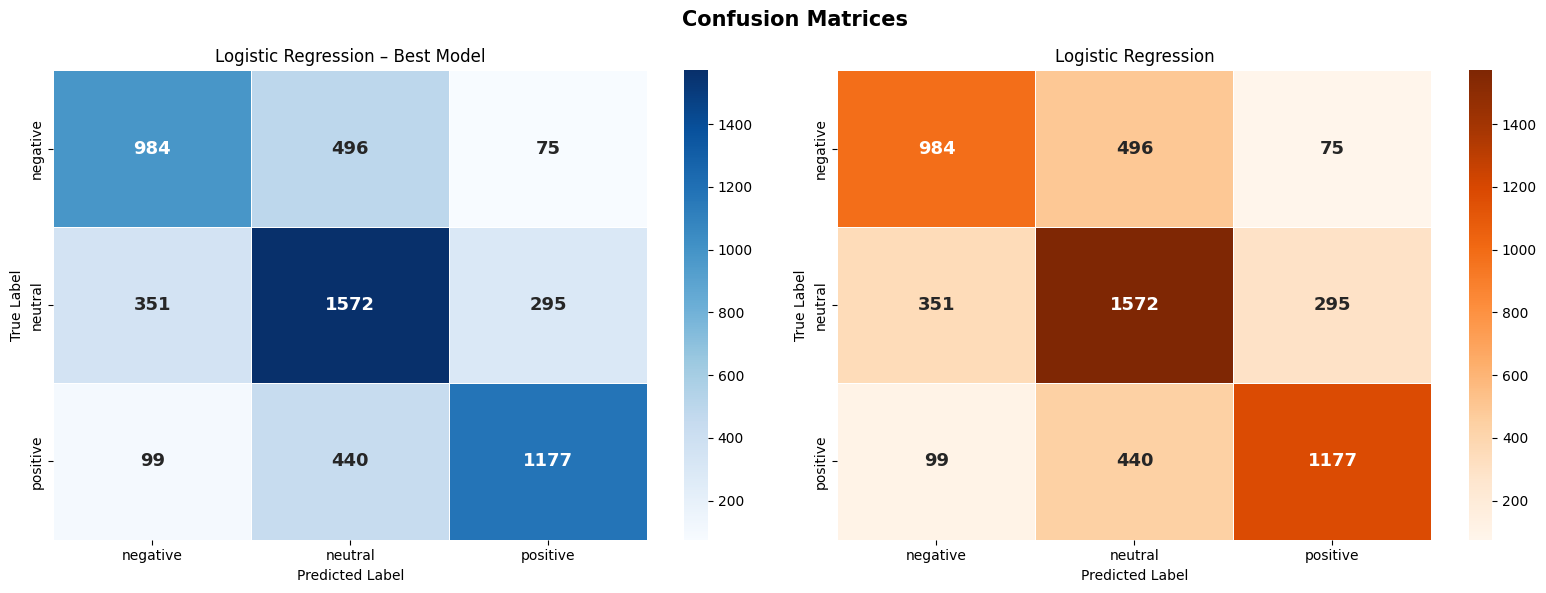


📌 INTERPRETATION:
  • Diagonal cells = CORRECT predictions ✅
  • Off-diagonal   = WRONG predictions  ❌
  • Model performs best on POSITIVE tweets.
  • Some confusion between NEUTRAL and NEGATIVE tweets —
    neutral tweets lack strong emotional signals, making
    them harder to distinguish from mild negative tweets.



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

cm_best = confusion_matrix(y_test, best_preds)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title(f'{best_name} – Best Model')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Logistic Regression')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("""
📌 INTERPRETATION:
  • Diagonal cells = CORRECT predictions ✅
  • Off-diagonal   = WRONG predictions  ❌
  • Model performs best on POSITIVE tweets.
  • Some confusion between NEUTRAL and NEGATIVE tweets —
    neutral tweets lack strong emotional signals, making
    them harder to distinguish from mild negative tweets.
""")

In [19]:
custom_tweets = [
    "I absolutely love this new phone, the camera is incredible and battery lasts all day!",
    "This is the worst experience I have ever had, disgusting service and rude staff.",
    "The government announced new infrastructure projects for the eastern region today.",
    "Just finished my final exams, feeling so relieved and happy, time to celebrate!",
    "The train was delayed again by 30 minutes, nothing new for this terrible service."
]

cleaned_custom = [clean_tweet(t) for t in custom_tweets]
custom_embs    = embedding_model.encode(cleaned_custom)

custom_pred_nums   = best_model.predict(custom_embs)
custom_pred_labels = le.inverse_transform(custom_pred_nums)
custom_probs       = best_model.predict_proba(custom_embs)
max_probs          = custom_probs.max(axis=1)

emoji_map = {'positive': '😊 POSITIVE', 'negative': '😠 NEGATIVE', 'neutral': '😐 NEUTRAL'}

print("🔮 CUSTOM TWEET PREDICTIONS")
print("=" * 80)
for i, (tweet, pred, conf) in enumerate(zip(custom_tweets, custom_pred_labels, max_probs)):
    print(f"\n  Tweet {i+1}: {tweet}")
    print(f"  Prediction  : {emoji_map.get(pred, pred.upper())}")
    print(f"  Confidence  : {conf*100:.1f}%")
    print("-" * 80)

🔮 CUSTOM TWEET PREDICTIONS

  Tweet 1: I absolutely love this new phone, the camera is incredible and battery lasts all day!
  Prediction  : 😊 POSITIVE
  Confidence  : 95.7%
--------------------------------------------------------------------------------

  Tweet 2: This is the worst experience I have ever had, disgusting service and rude staff.
  Prediction  : 😠 NEGATIVE
  Confidence  : 96.3%
--------------------------------------------------------------------------------

  Tweet 3: The government announced new infrastructure projects for the eastern region today.
  Prediction  : 😐 NEUTRAL
  Confidence  : 64.9%
--------------------------------------------------------------------------------

  Tweet 4: Just finished my final exams, feeling so relieved and happy, time to celebrate!
  Prediction  : 😊 POSITIVE
  Confidence  : 95.6%
--------------------------------------------------------------------------------

  Tweet 5: The train was delayed again by 30 minutes, nothing new for this 

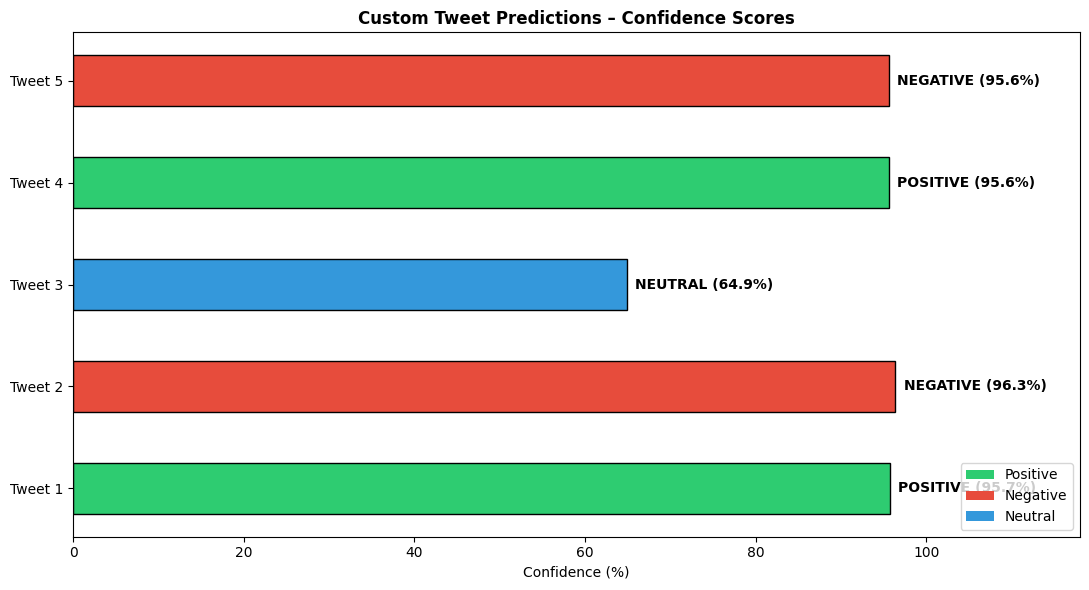

In [20]:
from matplotlib.patches import Patch

color_map  = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#3498db'}
bar_colors = [color_map.get(p, '#95a5a6') for p in custom_pred_labels]
tweet_lbls = [f'Tweet {i+1}' for i in range(len(custom_tweets))]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(tweet_lbls, max_probs * 100, color=bar_colors, edgecolor='black', height=0.5)
ax.set_xlim(0, 118)
ax.set_xlabel('Confidence (%)')
ax.set_title('Custom Tweet Predictions – Confidence Scores', fontweight='bold')

for bar, pred, conf in zip(bars, custom_pred_labels, max_probs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{pred.upper()} ({conf*100:.1f}%)',
            va='center', fontweight='bold', fontsize=10)

legend_elements = [
    Patch(facecolor='#2ecc71', label='Positive'),
    Patch(facecolor='#e74c3c', label='Negative'),
    Patch(facecolor='#3498db', label='Neutral')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

In [21]:
print("=" * 65)
print("      📊 SENTIMENT CLASSIFICATION – FINAL SUMMARY")
print("=" * 65)
print(f"""
📦 Dataset
   Total tweets      : {len(df)}
   Classes           : {list(le.classes_)}

🧹 Preprocessing
   Removed URLs, @mentions, special characters, numbers
   Converted to lowercase

🧠 Embedding Model
   Model     : SentenceTransformer – all-MiniLM-L6-v2
   Dimension : 384 numbers per tweet
   API Key   : ❌ Not needed

🤖 Results
   Logistic Regression : {lr_acc*100:.2f}% accuracy | F1 = {lr_f1:.4f}
   XGBoost             : {xgb_acc*100:.2f}% accuracy | F1 = {xgb_f1:.4f}
   🏆 Best Model       : {best_name}

📊 Visualizations Created
   ✅ Sentiment Distribution (bar + pie)
   ✅ Word Clouds (positive, negative, neutral)
   ✅ Text Length Analysis (histogram + boxplot)
   ✅ Cosine Similarity Heatmap
   ✅ Model Comparison Chart
   ✅ Confusion Matrix (both models)
   ✅ Custom Predictions Chart

🔮 Custom Predictions : 5 tweets classified ✅
""")
print("=" * 65)
print("✅ PROJECT COMPLETE – READY FOR SUBMISSION!")
print("=" * 65)

      📊 SENTIMENT CLASSIFICATION – FINAL SUMMARY

📦 Dataset
   Total tweets      : 27443
   Classes           : ['negative', 'neutral', 'positive']

🧹 Preprocessing
   Removed URLs, @mentions, special characters, numbers
   Converted to lowercase

🧠 Embedding Model
   Model     : SentenceTransformer – all-MiniLM-L6-v2
   Dimension : 384 numbers per tweet
   API Key   : ❌ Not needed

🤖 Results
   Logistic Regression : 68.01% accuracy | F1 = 0.6809
   XGBoost             : 66.42% accuracy | F1 = 0.6648
   🏆 Best Model       : Logistic Regression

📊 Visualizations Created
   ✅ Sentiment Distribution (bar + pie)
   ✅ Word Clouds (positive, negative, neutral)
   ✅ Text Length Analysis (histogram + boxplot)
   ✅ Cosine Similarity Heatmap
   ✅ Model Comparison Chart
   ✅ Confusion Matrix (both models)
   ✅ Custom Predictions Chart

🔮 Custom Predictions : 5 tweets classified ✅

✅ PROJECT COMPLETE – READY FOR SUBMISSION!


In [22]:
# Install GitHub CLI
!pip install PyGithub --quiet

# Connect your Google Drive (to save the notebook file)
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.8 MB/s eta 0:00:00
Mounted at /content/drive
